# 01 Mine Gazetteer

**Project:** Black Hills Mining Landscape Digital Twin Phase I
**Territory:** He Sapa (Black Hills) Unceded Lakota Territory
**Data Sources:** USGS MRDS (WFS), BLM LR2000

## Purpose
This notebook builds the foundational dataset of the entire twin:
a canonical mine gazetteer for He Sapa. Every mine record carries
full IEEE 2890-2025 provenance including the territorial acknowledgment.

The Lakota team members have not previously had access to a complete,
machine-readable spatial inventory of mines in He Sapa. This notebook
produces that inventory from public federal data in open formats.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    BLACK_HILLS_BBOX, COMMODITY_GROUPS, COMMODITY_COLORS,
    TREATY_PROVENANCE, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import load_mrds_mines, clean_mrds, load_black_hills_boundary
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# print(f"Repo root : {REPO_ROOT}")
print(f"Study area: {BLACK_HILLS_BBOX}")

Study area: (-104.6, 43.4, -103.3, 44.6)


In [2]:
# Print data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["mrds", "blm_claims"])


BLACK HILLS MINING DIGITAL TWIN TREATY TERRITORY ACKNOWLEDGMENT

He Sapa (the Black Hills) is unceded Lakota territory.

The 1868 Fort Laramie Treaty guaranteed He Sapa and surrounding lands to the Lakota
and their allies in perpetuity. After Custer's 1874 expedition confirmed gold, 
the US Congress unilaterally took the Black Hills in 1877. The US Supreme
Court ruled this action as unconstitutional in United States v. Sioux Nation of
Indians, 448 U.S. 371 (1980). The Sioux Nations have declined
the offered compensation. The Black Hills are not for sale.

Every record in this system carries that context as a provenance field.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oceti Sakowin and allied Nations have Ownership, Control, Access,
  and Possession of data describing their territory and resources.
  Phase I uses public federal data only. Any results describing
  He Sapa should be shared with relevant Lakota governance bodies
  before external publication or distribution.
  Reference: http

## Load MRDS Mine Records

In [3]:
# Query MRDS WFS for all mine records in He Sapa
# First run: live API query (~30 sec). Subsequent runs: cached.

mrds_raw = load_mrds_mines(bbox=BLACK_HILLS_BBOX)

print(f"Raw MRDS records: {len(mrds_raw):,}")
if not mrds_raw.empty:
    print(f"Columns: {mrds_raw.columns.tolist()}")
    print()
    print(mrds_raw.head(3).to_string())

Raw MRDS records: 1,719
Columns: ['dep_id', 'site_name', 'dev_stat', 'fips_code', 'huc_code', 'quad_code', 'url', 'code_list', 'geometry']

     dep_id                   site_name    dev_stat fips_code   huc_code   quad_code                                                         url code_list                     geometry
0  10008448  Moores, False Bottom Creek  Occurrence    f46081  h10120203  q45104SWB2  https://mrdata.usgs.gov/mrds/show-mrds.php?dep_id=10008448        MO  POINT (-103.81725 44.36663)
1  10055430       Homestake Mine - 1945    Producer    f46081  h10120202  q45104SWB2  https://mrdata.usgs.gov/mrds/show-mrds.php?dep_id=10055430     AU AG  POINT (-103.79454 44.36265)
2  10055431       Homestake Mine - 1946    Producer    f46081  h10120202  q45104SWB2  https://mrdata.usgs.gov/mrds/show-mrds.php?dep_id=10055431     AU AG  POINT (-103.79454 44.36265)


In [4]:
mrds = clean_mrds(mrds_raw)

def assign_commodity_group(commod):
    if pd.isna(commod):
        return "other"
    commod = str(commod).lower().strip()
    for group, terms in COMMODITY_GROUPS.items():
        if any(t in commod for t in terms):
            return group
    return "other"

if "commod1" in mrds.columns:
    mrds["commodity_group"] = mrds["commod1"].apply(assign_commodity_group)
else:
    mrds["commodity_group"] = "other"

print("COMMODITY DISTRIBUTION")
counts = mrds["commodity_group"].value_counts()
for comm, n in counts.items():
    bar = chr(9608) * int(n / max(counts) * 30)
    print(f"  {comm:<15}: {n:>4}  {bar}")

COMMODITY DISTRIBUTION
  other          : 1719  ██████████████████████████████


In [5]:
# Attach IEEE 2890-2025 provenance to every record
for field, value in TREATY_PROVENANCE.items():
    mrds[field] = value

mrds["prov_source"]     = "USGS Mineral Resources Data System (MRDS)"
mrds["prov_source_url"] = "https://mrdata.usgs.gov/mrds/"
mrds["ai_generated"]    = False
mrds["human_verified"]  = False

print(f"Provenance attached to {len(mrds):,} records")
print(f"  treaty_territory: {mrds['treaty_territory'].iloc[0]}")

Provenance attached to 1,719 records
  treaty_territory: 1868 Fort Laramie Treaty He Sapa (Black Hills)


## Summary Statistics

In [6]:
print("HE SAPA MINE GAZETTEER SUMMARY")
print(f"  Total records: {len(mrds):,}")

if "dev_stat" in mrds.columns:
    print("\n  By development status:")
    for status, n in mrds["dev_stat"].value_counts().items():
        print(f"    {str(status):<25}: {n:>4}")

if "commod1" in mrds.columns:
    print("\n  Top 10 commodities:")
    for commod, n in mrds["commod1"].value_counts().head(10).items():
        print(f"    {str(commod):<25}: {n:>4}")

bounds = mrds.total_bounds
print(f"\n  Bounding box: {bounds[0]:.3f}W {bounds[1]:.3f}N {bounds[2]:.3f}E {bounds[3]:.3f}N")

HE SAPA MINE GAZETTEER SUMMARY
  Total records: 1,719

  By development status:
    past producer            : 1008
    occurrence               :  289
    prospect                 :  247
    producer                 :  104
    unknown                  :   64
    plant                    :    7

  Bounding box: -104.598W 43.401N -103.300E 44.594N


## Map of MRDS Mines in He Sapa

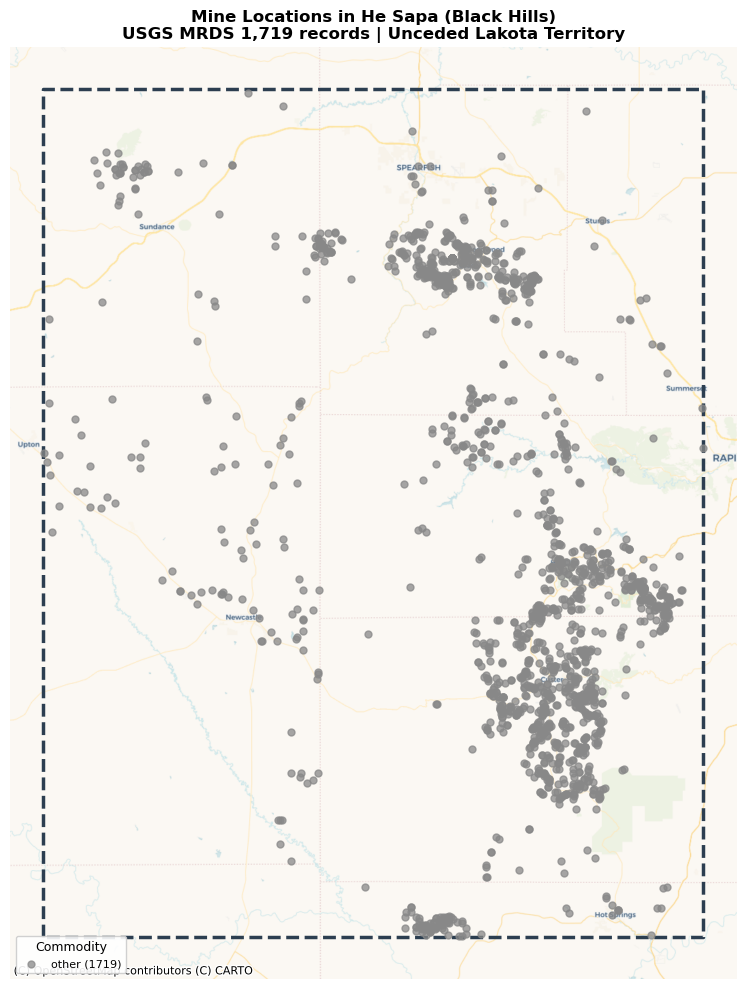

Saved: figures/01_mine_gazetteer.png


In [7]:
bh_boundary = load_black_hills_boundary()

fig, ax = plt.subplots(figsize=(12, 10))

bh_boundary.to_crs(3857).plot(
    ax=ax, facecolor="none", edgecolor="#2C3E50",
    linewidth=2.5, linestyle="--", zorder=2,
)

for group, color in COMMODITY_COLORS.items():
    subset = mrds[mrds["commodity_group"] == group]
    if subset.empty:
        continue
    subset.to_crs(3857).plot(
        ax=ax, color=color, markersize=25,
        alpha=0.75, zorder=3, label=f"{group} ({len(subset)})",
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=10)
except Exception:
    pass

ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, title="Commodity",
          title_fontsize=9, framealpha=0.9)
ax.set_title(
    f"Mine Locations in He Sapa (Black Hills)\n"
    f"USGS MRDS {len(mrds):,} records | Unceded Lakota Territory",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR/"01_mine_gazetteer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/01_mine_gazetteer.png")

## Export Gazetteer

In [8]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

mrds.to_file(OUTPUTS_DIR / "he_sapa_mine_gazetteer.gpkg", driver="GPKG", layer="mrds_mines")
mrds.to_file(OUTPUTS_DIR / "he_sapa_mine_gazetteer.geojson", driver="GeoJSON")
mrds.drop(columns="geometry").to_csv(OUTPUTS_DIR / "he_sapa_mine_gazetteer.csv", index=False)

print("Exported:")
print("  outputs/he_sapa_mine_gazetteer.gpkg    (GIS primary)")
print("  outputs/he_sapa_mine_gazetteer.geojson (web / Folium)")
print("  outputs/he_sapa_mine_gazetteer.csv     (tabular analysis)")
print(f"\nTotal records: {len(mrds):,}")
print(f"Treaty provenance on every record: {mrds['treaty_territory'].iloc[0]}")

Exported:
  outputs/he_sapa_mine_gazetteer.gpkg    (GIS primary)
  outputs/he_sapa_mine_gazetteer.geojson (web / Folium)
  outputs/he_sapa_mine_gazetteer.csv     (tabular analysis)

Total records: 1,719
Treaty provenance on every record: 1868 Fort Laramie Treaty He Sapa (Black Hills)


In [9]:
print(generate_citations(["mrds", "blm_claims"]))


USGS Mineral Resources Data System (MRDS)
  US Geological Survey. Mineral Resources Data System (MRDS). https://mrdata.usgs.gov/mrds/ doi:10.3133/ds20
  https://mrdata.usgs.gov/mrds/
  Steward: US Geological Survey | License: Public domain (USGS)

BLM LR2000 Mining Claims for South Dakota
  https://www.blm.gov/lr2000
  Steward: Bureau of Land Management | License: Public domain (BLM)

TERRITORIAL PROVENANCE (all records)
  1868 Fort Laramie Treaty He Sapa (Black Hills)
  Unceded Lakota territory. The 1877 Congressional act taking He Sapa was ruled unconstitutional by the US Supreme Court in United States v. Sioux Nation of Indians (1980). The Treaty Nations have declined compensation, maintaining that the land was never legally transferred.
  United States v. Sioux Nation of Indians, 448 U.S. 371 (1980)
  TK Label: TK Notice Indigenous interests exist in all records describing He Sapa. Contact originating Lakota communities before use. See: https://localcontexts.org/label/tk-notice/

